## Import required libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import os
import math
import warnings
import numpy as np

import gzip
import re

warnings.filterwarnings('ignore')

## Set file paths and directories

In [2]:
# Set data and output directories
root = '/home/ext_sana_noor_astraeabio_com/ext_hd/chiba'
data_dir = root+'data/'
out = root+'out_july2025_xenium/'

# save outputs and tables
save_tables_path = out+'script05_tables/'
os.makedirs(save_tables_path, exist_ok=True)

# directory for reduced gbmap
gbmap_dir = '/home/ext_sana_noor_astraeabio_com/ext_hd/chiba/out_feb2025_xenium/script02a_gbmap_reduced/'

## Load reference AnnData (reduced/filtered gbmap)

In [ ]:
gbmap = sc.read_h5ad(f'{gbmap_dir}gbmap_reduced.h5ad') # read the filtered gbmap AnnData object via scanpy
gbmap # display gbmap structure

AnnData object with n_obs × n_vars = 1135677 × 356
    obs: 'author', 'donor_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'organism_ontology_term_id', 'sex_ontology_term_id', 'annotation_level_1', 'annotation_level_2', 'annotation_level_3', 'gbmap', 'method', 'stage', 'location', 'sector', 'celltype_original', 'EGFR', 'MET', 'p53', 'TERT', 'ATRX', 'PTEN', 'MGMT', 'chr1p19q', 'PDGFR', 'suspension_type', 'tissue_ontology_term_id', 'tissue_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_types', 'genome', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    u

## Choose annotation columns for transfer


In [4]:
annotations_to_compare = ['annotation_level_1', 'annotation_level_2', 'annotation_level_3', 'celltype_original', 'cell_type']
#annotations_to_compare = ['annotation_level_3']

## Evaluate annotation labels

In [ ]:
#[print(label) for label in gbmap.obs[annotations_to_compare[0]].unique()]
print(gbmap.obs[annotations_to_compare[0]].unique().tolist())

Neoplastic
Non-neoplastic


[None, None]

### Lists all files (AnnData per core) already saved in the directory

In [ ]:
xenium_cores = os.listdir('/home/ext_sana_noor_astraeabio_com/ext_hd/chiba/out_july2025_xenium/script01_adatas/')
xenium_cores # displays the list

['adata_GBM10-Edge.h5ad',
 'adata_Oligo2_Edge.h5ad',
 'adata_Oligo5_Edge.h5ad',
 'adata_GBM4-Edge.h5ad',
 'adata_GBM2-Core.h5ad',
 'adata_GBM8-Core.h5ad',
 'adata_AA1_Edge.h5ad',
 'adata_GBM6-Edge.h5ad',
 'adata_OligoGr3_Edge.h5ad',
 'adata_AA3_Edge.h5ad',
 'adata_Control_1.h5ad',
 'adata_AA2__Core.h5ad',
 'adata_GBM10-Core.h5ad',
 'adata_GBM3-Core.h5ad',
 'adata_AA1_Core.h5ad',
 'adata_GBM1-Edge.h5ad',
 'adata_GBM3-Edge.h5ad',
 'adata_GBM9-Core.h5ad',
 'adata_Oligo1_Edge.h5ad',
 'adata_GBM7-Edge.h5ad',
 'adata_Control_2.h5ad',
 'adata_Oligo5_Core.h5ad',
 'adata_Oligo3_Edge.h5ad',
 'adata_Oligo1_Core.h5ad',
 'adata_GBM5-Edge.h5ad',
 'adata_AA2_Edge.h5ad',
 'adata_GBM1-Core.h5ad',
 'adata_GBM7-Core.h5ad',
 'adata_Oligo4_Core.h5ad',
 'adata_Oligo3__Core.h5ad',
 'adata_GBM9-Edge.h5ad',
 'adata_Oligo4_Edge.h5ad',
 'adata_GBM4-Core.h5ad',
 'adata_GBM8-Edge.h5ad',
 'adata_GBM6-Core.h5ad',
 'adata_AA3_Core.h5ad',
 'adata_Oligo2_Core.h5ad',
 'adata_OligoGr3_Core.h5ad',
 'adata_GBM2-Edge.h5ad',

### Inspect gbmap gene metadata

In [ ]:
gbmap.var #Displays gene metadata from reference AnnData to quickly check metadata columns of gbmap

,feature_types,genome,highly_variable,means,dispersions,dispersions_norm,highly_variable_nbatches,highly_variable_intersection,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type
ENSG00000069431,Gene Expression,unknown,True,0.048896,0.560783,0.416098,12,False,False,ABCC9,NCBITaxon:9606,gene,3237,protein_coding
ENSG00000107796,Gene Expression,unknown,True,0.095108,1.782721,3.294586,21,False,False,ACTA2,NCBITaxon:9606,gene,1655,protein_coding
ENSG00000151388,Gene Expression,unknown,False,0.010155,0.465181,0.053402,8,False,False,ADAMTS12,NCBITaxon:9606,gene,1873,protein_coding
ENSG00000145536,Gene Expression,unknown,False,0.002550,0.147399,-0.236115,3,False,False,ADAMTS16,NCBITaxon:9606,gene,2954,protein_coding
ENSG00000156140,Gene Expression,unknown,True,0.015092,0.562868,0.269604,8,False,False,ADAMTS3,NCBITaxon:9606,gene,1002,protein_coding
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000146469,Gene Expression,unknown,False,0.001308,0.292876,0.383037,6,False,False,VIP,NCBITaxon:9606,gene,1580,protein_coding
ENSG00000174453,Gene Expression,unknown,True,0.020639,0.429211,0.224688,8,False,False,VWC2L,NCBITaxon:9606,gene,4480,protein_coding
ENSG00000156076,Gene Expression,unknown,True,0.007260,0.548932,0.560472,12,False,False,WIF1,NCBITaxon:9606,gene,568,protein_coding
ENSG00000169064,Gene Expression,unknown,False,0.011156,0.379737,-0.038398,6,False,False,ZBBX,NCBITaxon:9606,gene,756,protein_coding


## Annotate cells using gbmap labels

For each Xenium core, for each annotation, it computes the Pearson correlation of each Xenium cell with the mean gene expression profiles of annotated gbmap groups, and assigns the most correlated annotation label and its correlation value.

1. Loops through files and annotation levels.
2. Intersects genes.
3. Builds mean group expression (reference).
4. Computes correlations for all cells.
5. Assigns best-match label and value to .obs.
6. Writes new annotated AnnData.

In [8]:
import tqdm

new_annotated_core_path = out + 'script05_gbmap_annotated_xenium_adatas/'
os.makedirs(new_annotated_core_path, exist_ok=True)

xe_list = []

for xenium_core in tqdm.tqdm(xenium_cores):
    df_gbmap = pd.DataFrame(gbmap.X.toarray(), index=gbmap.obs.index, columns=gbmap.var.feature_name)
    xe = sc.read_h5ad(f'/home/ext_sana_noor_astraeabio_com/ext_hd/chiba/out_july2025_xenium/script01_adatas/{xenium_core}')
    print(f'Beginning correlation analysis for Core: {xenium_core}')

    for annotation in annotations_to_compare:  
        print(f'--- Annotation: {annotation}')
        df_gbmap = df_gbmap.loc[:, df_gbmap.columns[df_gbmap.columns.isin(xe.var.index)]] 
        shared_genes = df_gbmap.columns[df_gbmap.columns.isin(xe.var.index)]

        df_gbmap = df_gbmap.loc[:, shared_genes]
        xe = xe[:, shared_genes]
        xdf = pd.DataFrame(xe.X.toarray(), index=xe.obs.index, columns=xe.var.index)[df_gbmap.T.index].T

        print(f'------ shape of gbmap after filtering: {df_gbmap.shape}')
        df_gbmap['annotation'] = gbmap.obs[annotation]
        df = df_gbmap.groupby('annotation').mean().rename_axis('', axis=1).rename_axis('', axis=0).T

        print(f'------ shape of gbmap after grouping: {df.shape} \n')
        
        ### calculate pearon correlation for each xenium cell with the averaged cell type scores from gbmap df above
        ### empty list to store the correlation values
        final_correlations = []


        for column in xdf.columns:
            corrs = []
            for column2 in df.columns:
                corr = xdf[column].corr(df[column2])
                corrs.append(corr)
            
            final_correlations.append(pd.DataFrame(corrs))
            
        
        final_correlations = pd.concat(final_correlations, axis=1)
        final_correlations.columns = xdf.columns
        final_correlations.index = df.columns    


        scores = final_correlations.idxmax(axis=0)
        values = final_correlations.max(axis=0)
        scores = scores.reindex(xe.obs.index)
        values = values.reindex(xe.obs.index)

        xe.obs[f'{annotation}'] = scores.values  
        xe.obs[f'{annotation}_corr'] = values.values
    xe.write(new_annotated_core_path + xenium_core)
    xe_list.append(xe)

  0%|          | 0/40 [00:00<?, ?it/s]

Beginning correlation analysis for Core: adata_GBM10-Edge.h5ad
--- Annotation: annotation_level_1
------ shape of gbmap after filtering: (1135677, 356)
------ shape of gbmap after grouping: (356, 2) 

--- Annotation: annotation_level_2
------ shape of gbmap after filtering: (1135677, 356)
------ shape of gbmap after grouping: (356, 6) 

--- Annotation: annotation_level_3
------ shape of gbmap after filtering: (1135677, 356)
------ shape of gbmap after grouping: (356, 21) 

--- Annotation: celltype_original
------ shape of gbmap after filtering: (1135677, 356)
------ shape of gbmap after grouping: (356, 105) 

--- Annotation: cell_type
------ shape of gbmap after filtering: (1135677, 356)
------ shape of gbmap after grouping: (356, 18) 



  2%|▎         | 1/40 [00:48<31:44, 48.83s/it]

Beginning correlation analysis for Core: adata_Oligo2_Edge.h5ad
--- Annotation: annotation_level_1
------ shape of gbmap after filtering: (1135677, 356)
------ shape of gbmap after grouping: (356, 2) 

--- Annotation: annotation_level_2
------ shape of gbmap after filtering: (1135677, 356)
------ shape of gbmap after grouping: (356, 6) 

--- Annotation: annotation_level_3
------ shape of gbmap after filtering: (1135677, 356)
------ shape of gbmap after grouping: (356, 21) 

--- Annotation: celltype_original
------ shape of gbmap after filtering: (1135677, 356)
------ shape of gbmap after grouping: (356, 105) 

--- Annotation: cell_type
------ shape of gbmap after filtering: (1135677, 356)
------ shape of gbmap after grouping: (356, 18) 



  5%|▌         | 2/40 [02:14<44:31, 70.29s/it]

...

 95%|█████████▌| 38/40 [58:05<03:27, 103.60s/it]

Beginning correlation analysis for Core: adata_GBM2-Edge.h5ad
--- Annotation: annotation_level_1
------ shape of gbmap after filtering: (1135677, 356)
------ shape of gbmap after grouping: (356, 2) 

--- Annotation: annotation_level_2
------ shape of gbmap after filtering: (1135677, 356)
------ shape of gbmap after grouping: (356, 6) 

--- Annotation: annotation_level_3
------ shape of gbmap after filtering: (1135677, 356)
------ shape of gbmap after grouping: (356, 21) 

--- Annotation: celltype_original
------ shape of gbmap after filtering: (1135677, 356)
------ shape of gbmap after grouping: (356, 105) 

--- Annotation: cell_type
------ shape of gbmap after filtering: (1135677, 356)
------ shape of gbmap after grouping: (356, 18) 



 98%|█████████▊| 39/40 [59:03<01:29, 89.80s/it] 

Beginning correlation analysis for Core: adata_GBM5-Core.h5ad
--- Annotation: annotation_level_1
------ shape of gbmap after filtering: (1135677, 356)
------ shape of gbmap after grouping: (356, 2) 

--- Annotation: annotation_level_2
------ shape of gbmap after filtering: (1135677, 356)
------ shape of gbmap after grouping: (356, 6) 

--- Annotation: annotation_level_3
------ shape of gbmap after filtering: (1135677, 356)
------ shape of gbmap after grouping: (356, 21) 

--- Annotation: celltype_original
------ shape of gbmap after filtering: (1135677, 356)
------ shape of gbmap after grouping: (356, 105) 

--- Annotation: cell_type
------ shape of gbmap after filtering: (1135677, 356)
------ shape of gbmap after grouping: (356, 18) 



100%|██████████| 40/40 [1:01:51<00:00, 92.79s/it] 


## Distribution of assigned annotations (basic QC)

In [ ]:
xe_list[0].obs['annotation_level_3'].value_counts() #Shows count of assigned level 3 annotations for the first processed core

annotation_level_3
Astrocyte          691
TAM-MG             209
Oligodendrocyte    190
AC-like            185
Endothelial        162
Neuron             115
OPC-like           113
Mural cell          93
MES-like            86
NPC-like            61
OPC                 17
TAM-BDM             13
Plasma B             9
Neutrophil           5
Mono                 4
DC                   2
B cell               1
Mast                 1
CD4/CD8              1
Name: count, dtype: int64

In [ ]:
xe_list[2].obs['annotation_level_3'].value_counts() #Shows annotation distribution for the third processed core

annotation_level_3
OPC-like           864
Astrocyte          733
NPC-like           538
AC-like             64
Oligodendrocyte     50
Endothelial         42
TAM-MG              30
Mural cell          15
Neuron               8
OPC                  2
MES-like             1
Name: count, dtype: int64

In [ ]:
final_correlations.to_csv(save_tables_path + 'final_correlations.csv') #save output correlations as csv file

<Axes: >

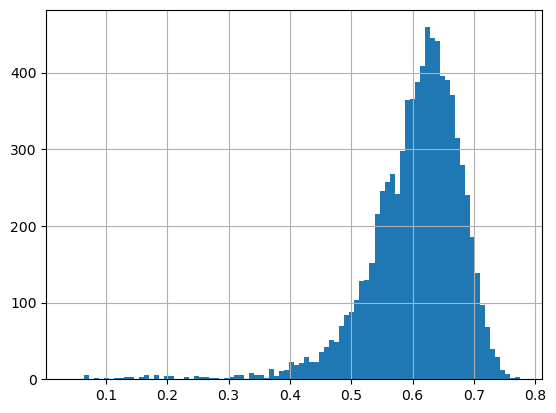

In [ ]:
final_correlations.max(axis=0).hist(bins=90) #histogram to inspect the correlation

In [ ]:
final_correlations.max(axis=0).describe() #description of the correlation

count    8179.000000
mean        0.603524
std         0.078356
min         0.039813
25%         0.566133
50%         0.616235
75%         0.654925
max         0.774628
dtype: float64

(array([1.22264335e-04, 1.22264335e-04, 1.22264335e-04, 1.22264335e-04,
        1.22264335e-04, 1.22264335e-04, 1.22264335e-04, 1.22264335e-04,
        2.44528671e-04, 7.33586013e-04, 7.33586013e-04, 7.33586013e-04,
        7.33586013e-04, 8.55850348e-04, 1.10037902e-03, 1.10037902e-03,
        1.10037902e-03, 1.10037902e-03, 1.22264335e-03, 1.34490769e-03,
        1.46717203e-03, 1.46717203e-03, 1.46717203e-03, 1.46717203e-03,
        1.46717203e-03, 1.58943636e-03, 1.58943636e-03, 1.83396503e-03,
        1.95622937e-03, 1.95622937e-03, 2.07849370e-03, 2.07849370e-03,
        2.20075804e-03, 2.68981538e-03, 2.68981538e-03, 2.68981538e-03,
        2.68981538e-03, 2.68981538e-03, 2.81207972e-03, 2.93434405e-03,
        3.05660839e-03, 3.17887272e-03, 3.54566573e-03, 3.66793006e-03,
        3.79019440e-03, 3.79019440e-03, 3.79019440e-03, 3.91245874e-03,
        4.27925174e-03, 4.52378041e-03, 4.52378041e-03, 4.64604475e-03,
        4.64604475e-03, 5.01283776e-03, 5.13510209e-03, 5.257366

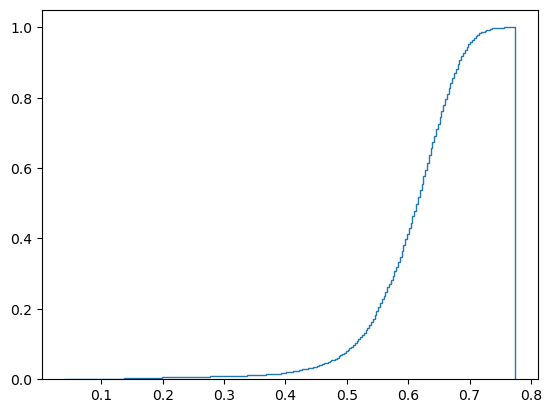

In [14]:
### plot a cdf
plt.hist(final_correlations.max(axis=0), bins=250, cumulative=True, density=True, histtype='step')